# Пример чтения файлов формата `.bag`
В данном блокноте приведен пример чтения технических данных из Робота Unitree A1 ИТ-Центра МАИ по имени Дора.
Данный формат широко распространен для записи технических параметров в системах ROS

Установка необходимых пакетов

In [ ]:
%pip install bagpy

Подключаем необходимые библиотеки:

In [1]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
b = bagreader('20230117_183740.bag')

[INFO]  Successfully created the data folder 20230117_183740.


Посмотрим какие данные сохранены в файле

In [3]:
#Если хотим посмотреть все топики в файле
#pd.set_option('display.max_rows', None)
b.topic_table

,Topics,Types,Message Count,Frequency
0,/device_0/info,diagnostic_msgs/KeyValue,13,NaN
1,/device_0/sensor_0/Depth_0/image/data,sensor_msgs/Image,394,14.988542
2,/device_0/sensor_0/Depth_0/image/metadata,diagnostic_msgs/KeyValue,9456,NaN
3,/device_0/sensor_0/Depth_0/info,realsense_msgs/StreamInfo,1,NaN
4,/device_0/sensor_0/Depth_0/info/camera_info,sensor_msgs/CameraInfo,1,NaN
...,...,...,...,...
102,/device_0/sensor_2/option/Frames_Queue_Size/de...,std_msgs/String,1,NaN
103,/device_0/sensor_2/option/Frames_Queue_Size/value,std_msgs/Float32,1,NaN
104,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/String,1,NaN
105,/device_0/sensor_2/option/Global_Time_Enabled/...,std_msgs/Float32,1,NaN


## Декодирование сообщений из топика

In [4]:
msgsImu_MSG = b.message_by_topic('/device_0/sensor_2/Accel_0/imu/data')
msgsImu_MSG

'20230117_183740/device_0-sensor_2-Accel_0-imu-data.csv'

In [5]:
df_msgsImu = pd.read_csv(msgsImu_MSG)
df_msgsImu

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2586,26.254508,50074,1673969886,483981609,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2587,26.264428,50075,1673969886,493787050,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2588,26.274125,50076,1673969886,503591537,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2589,26.283836,50077,1673969886,513395786,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Построим график для линейного ускорения датчика по оси Y.
Обратите внимание, что датчик в процессе эксперимента не перемещался, на него воздействовали лишь вибрации от вентилляторов, расположенных в корпусе робота.

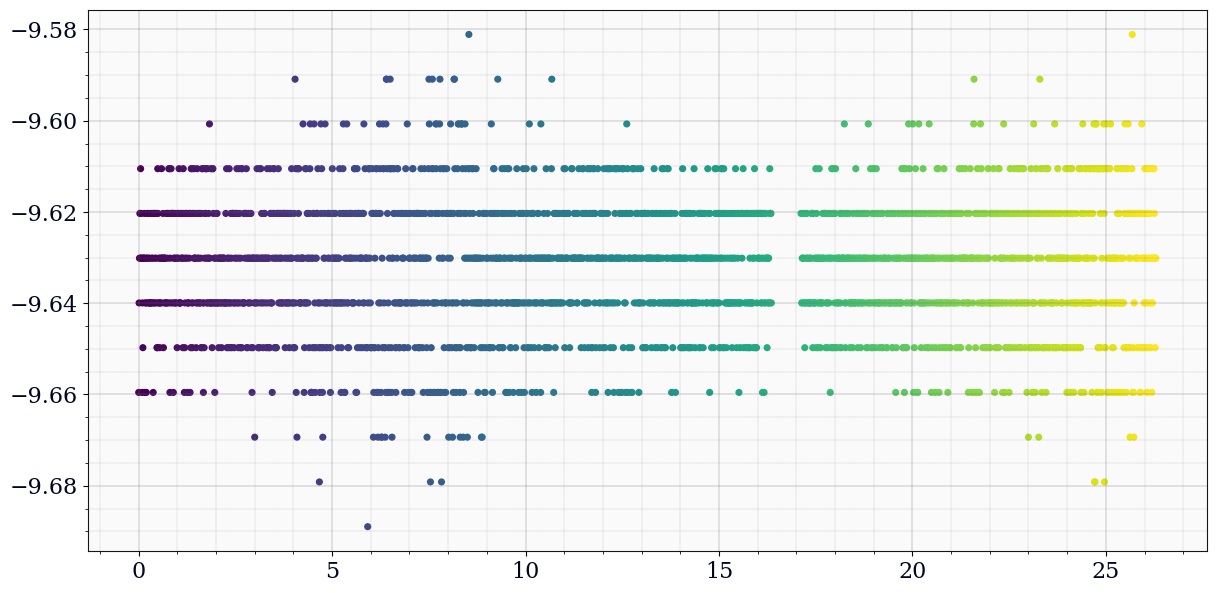

In [6]:
fig, ax = bagpy.create_fig(1)
ax[0].scatter(x='Time', y='linear_acceleration.y', data=df_msgsImu, s= 17, c = 'Time')
plt.show()

## Заглянем в цветную камеру и камеру глубины
На борту робота установлена цветная камера и камера глубины, которые осуществляли съемку в процессе записи bag файла. Доступ к данным можно получить аналогичным способом

In [7]:
sensor_msgsImage_MSG_depth = b.message_by_topic('/device_0/sensor_0/Depth_0/image/data')
sensor_msgsImage_MSG_rgb = b.message_by_topic('/device_0/sensor_1/Color_0/image/data')
sensor_msgsImage_MSG_rgb

'20230117_183740/device_0-sensor_1-Color_0-image-data.csv'

In [8]:
df_sensor_msgsImage = pd.read_csv(sensor_msgsImage_MSG_rgb)
df_sensor_msgsImage

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.039579,6994,1673969860,210257769,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8d\x94\x8d\x8c...
1,0.106640,6995,1673969860,276888609,1,480,640,rgb8,0,1920,b'\x8c\x8b\x90\x8c\x8b\x90\x8d\x8b\x95\x8c\x8a...
2,0.174092,6996,1673969860,343518496,1,480,640,rgb8,0,1920,b'\x8c\x8e\x96\x8c\x8e\x96\x8a\x8e\x95\x8a\x8e...
3,0.239945,6997,1673969860,410146952,1,480,640,rgb8,0,1920,b'\x8e\x8c\x96\x8d\x8b\x95\x8d\x8b\x95\x8c\x8a...
4,0.307951,6998,1673969860,476774216,1,480,640,rgb8,0,1920,b'\x8d\x8c\x93\x8d\x8c\x93\x8e\x8a\x93\x90\x8b...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.994066,7383,1673969886,155333042,1,480,640,rgb8,0,1920,b'\x88\x89\x91\x87\x88\x90\x87\x85\x8f\x88\x87...
390,26.058981,7384,1673969886,221859217,1,480,640,rgb8,0,1920,b'\x86\x8b\x8f\x85\x8a\x8e\x89\x88\x8f\x89\x88...
391,26.128662,7385,1673969886,288382292,1,480,640,rgb8,0,1920,b'\x86\x8c\x8d\x86\x8c\x8d\x84\x89\x8b\x86\x8c...
392,26.192559,7386,1673969886,354902267,1,480,640,rgb8,0,1920,b'\x87\x86\x8d\x87\x86\x8d\x88\x87\x8e\x88\x87...


In [9]:
df_sensor_msgsImage_depth = pd.read_csv(sensor_msgsImage_MSG_depth)
df_sensor_msgsImage_depth

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,height,width,encoding,is_bigendian,step,data
0,0.033964,6991,1673969860,210136890,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
1,0.101118,6992,1673969860,276767731,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
2,0.167259,6993,1673969860,343397617,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
3,0.234002,6994,1673969860,410026073,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
4,0.300807,6995,1673969860,476653337,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
...,...,...,...,...,...,...,...,...,...,...,...
389,25.986207,7380,1673969886,155212402,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
390,26.053176,7381,1673969886,221738577,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
391,26.119521,7382,1673969886,288261414,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...
392,26.186304,7383,1673969886,354781628,1,480,640,mono16,0,1280,b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...


Далее можно считать изображение из Pandas DataFrame, однако в таком формате его использовать неудобно, поэтому добавим немного магии для преобразования в удобный вид цветного изображения

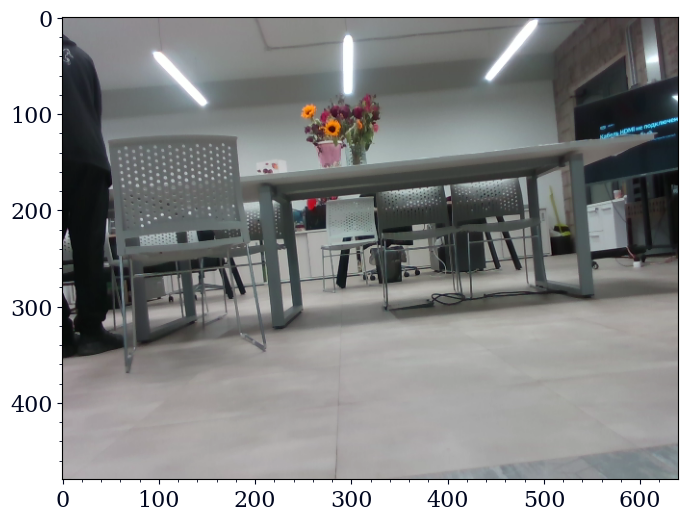

In [10]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

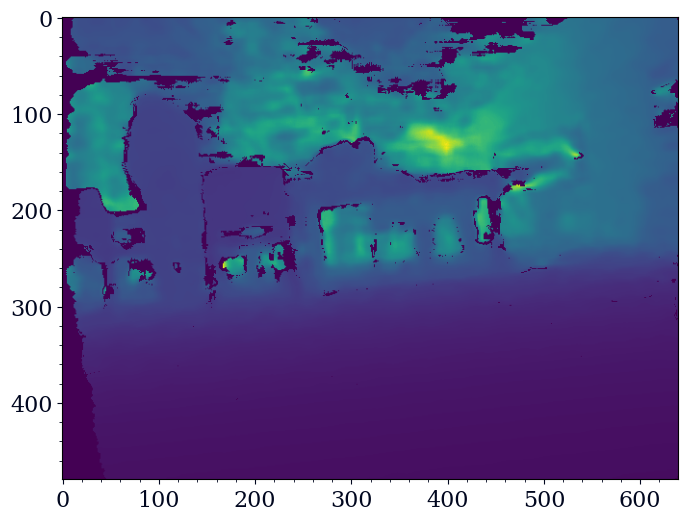

In [11]:
# size of image
H = 480
W = 640

# receive the image we are interested in from the Pandas DataFrame
raw_string = df_sensor_msgsImage_depth['data'][0]

# convert to byte string with escape characters included
byte_string = raw_string[2:-1].encode('latin1')

# remove escaped characters
escaped_string = byte_string.decode('unicode_escape')

# convert back to byte string without escaped characters
byte_string = escaped_string.encode('latin1')

# convert string to numpy array
nparr = np.frombuffer(byte_string, np.uint8)

# convert to 3 channel rgb image array of (H x W x 3)
rgb = nparr.view(np.uint16).reshape((H, W, -1))

# show image in matplotlib
plt.imshow(rgb)

## Практическое задание
* Попробуйте считать какие-либо параметры датчиков из данного файла, например, акселерометра
* Постройте параметры в виде графиков в matplotlib

In [12]:
# Считываем данные акселерометра
msgs_accel = b.message_by_topic('/device_0/sensor_2/Accel_0/imu/data')
df_accel = pd.read_csv(msgs_accel)

df_accel.head()

,Time,header.seq,header.stamp.secs,header.stamp.nsecs,header.frame_id,orientation.x,orientation.y,orientation.z,orientation.w,orientation_covariance_0,...,linear_acceleration.z,linear_acceleration_covariance_0,linear_acceleration_covariance_1,linear_acceleration_covariance_2,linear_acceleration_covariance_3,linear_acceleration_covariance_4,linear_acceleration_covariance_5,linear_acceleration_covariance_6,linear_acceleration_covariance_7,linear_acceleration_covariance_8
0,0.000383,47404,1673969860,238107681,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.010330,47405,1673969860,247928381,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.020583,47406,1673969860,257749557,1,0.0,0.0,0.0,0.0,0.0,...,-0.098066,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.030097,47407,1673969860,267572165,1,0.0,0.0,0.0,0.0,0.0,...,-0.107873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.041590,47408,1673969860,277393103,1,0.0,0.0,0.0,0.0,0.0,...,-0.117680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Посмотрим, какие параметры есть в таблице
df_accel.columns

Index(['Time', 'header.seq', 'header.stamp.secs', 'header.stamp.nsecs',
       'header.frame_id', 'orientation.x', 'orientation.y', 'orientation.z',
       'orientation.w', 'orientation_covariance_0', 'orientation_covariance_1',
       'orientation_covariance_2', 'orientation_covariance_3',
       'orientation_covariance_4', 'orientation_covariance_5',
       'orientation_covariance_6', 'orientation_covariance_7',
       'orientation_covariance_8', 'angular_velocity.x', 'angular_velocity.y',
       'angular_velocity.z', 'angular_velocity_covariance_0',
       'angular_velocity_covariance_1', 'angular_velocity_covariance_2',
       'angular_velocity_covariance_3', 'angular_velocity_covariance_4',
       'angular_velocity_covariance_5', 'angular_velocity_covariance_6',
       'angular_velocity_covariance_7', 'angular_velocity_covariance_8',
       'linear_acceleration.x', 'linear_acceleration.y',
       'linear_acceleration.z', 'linear_acceleration_covariance_0',
       'linear_accelerat

In [14]:
# Оставим только время и ускорения по осям X, Y, Z
accel_data = df_accel[
    [
        'Time',
        'linear_acceleration.x',
        'linear_acceleration.y',
        'linear_acceleration.z'
    ]
]

accel_data.head()

,Time,linear_acceleration.x,linear_acceleration.y,linear_acceleration.z
0,0.000383,-1.108151,-9.659550,-0.107873
1,0.010330,-1.117958,-9.639936,-0.107873
2,0.020583,-1.108151,-9.630130,-0.098066
3,0.030097,-1.098345,-9.620323,-0.107873
4,0.041590,-1.088538,-9.630130,-0.117680


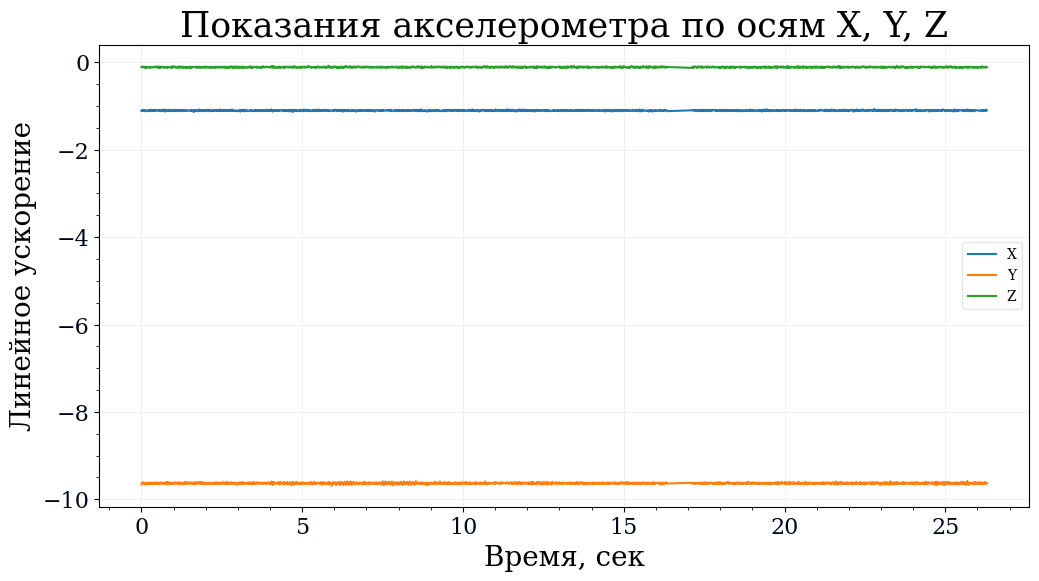

In [15]:
# График ускорения по трём осям
plt.figure(figsize=(12, 6))

plt.plot(accel_data['Time'], accel_data['linear_acceleration.x'], label='X')
plt.plot(accel_data['Time'], accel_data['linear_acceleration.y'], label='Y')
plt.plot(accel_data['Time'], accel_data['linear_acceleration.z'], label='Z')

plt.title('Показания акселерометра по осям X, Y, Z')
plt.xlabel('Время, сек')
plt.ylabel('Линейное ускорение')
plt.legend()
plt.grid(True)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18772\3623232143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  accel_data['acceleration_module'] = np.sqrt(


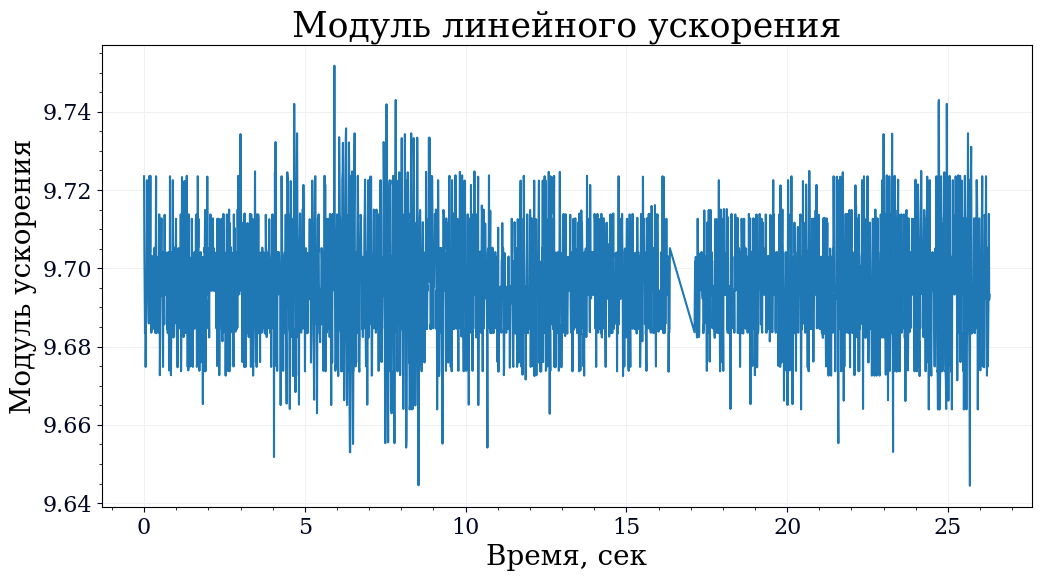

In [16]:
accel_data['acceleration_module'] = np.sqrt(
    accel_data['linear_acceleration.x']**2 +
    accel_data['linear_acceleration.y']**2 +
    accel_data['linear_acceleration.z']**2
)

plt.figure(figsize=(12, 6))
plt.plot(accel_data['Time'], accel_data['acceleration_module'])

plt.title('Модуль линейного ускорения')
plt.xlabel('Время, сек')
plt.ylabel('Модуль ускорения')
plt.grid(True)

plt.show()

## Дополнительная информация
Дополнительная информация по данному пакету доступна по [ссылке](https://pypi.org/project/bagpy/)